# Notebook 04: Forecasting Models
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Build and compare ARIMA, Linear Regression, and XGBoost forecasting models

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR = Path('../outputs/figures')
MODELS_DIR = Path('../outputs/models')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA, parse_dates=['last_updated'])
print(f"Loaded: {df.shape}")

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-9))) * 100
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    return {'Model': name, 'MAE': round(mae,4),
            'RMSE': round(rmse,4), 'R2': round(r2,4),
            'MAPE': round(mape,2)}

Loaded: (144822, 39)


## 1. Prepare Time Series Data

Time series length: 747 days
Range: 2024-05-16 00:00:00 → 2026-06-01 00:00:00

Train: 687 days (until 2026-04-02)
Test:  60 days (from 2026-04-03)


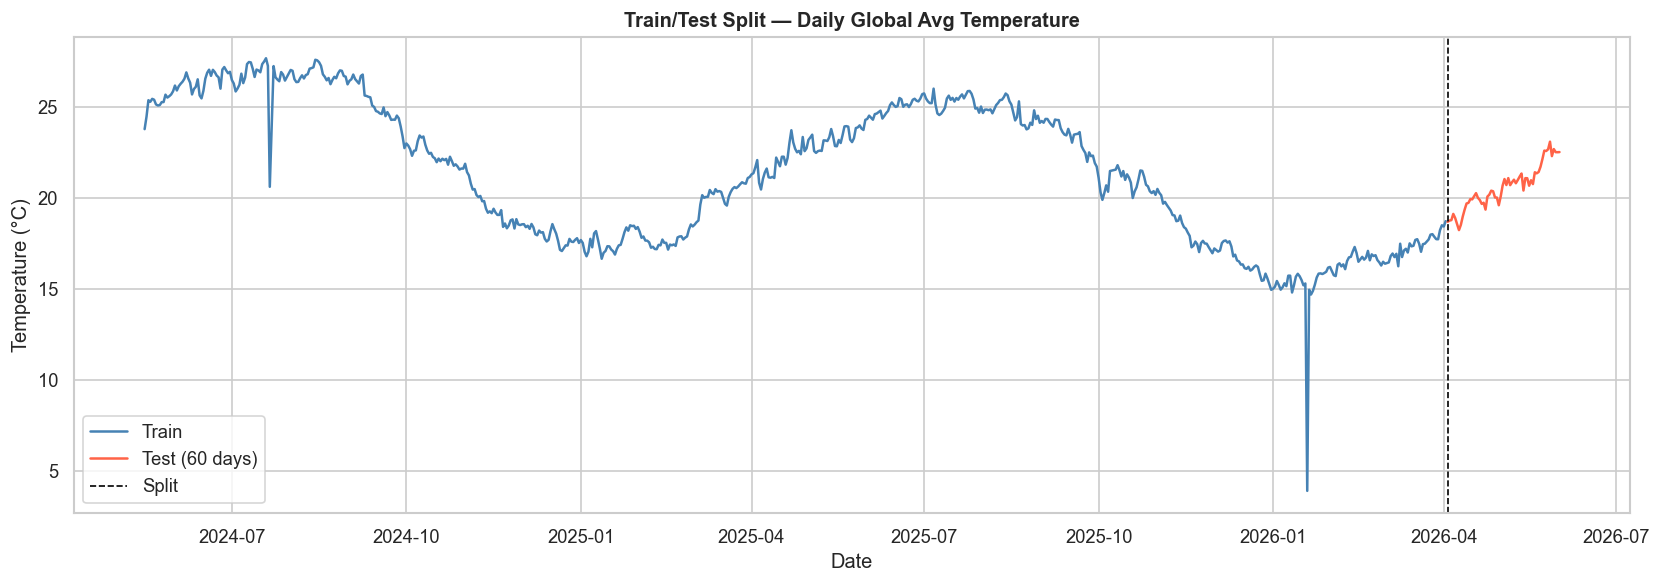

Saved: 18_train_test_split.png


In [31]:
# Daily global average temperature
daily_temp = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()
daily_temp.index = pd.to_datetime(daily_temp.index)
daily_temp = daily_temp.sort_index().asfreq('D').interpolate()

print(f"Time series length: {len(daily_temp)} days")
print(f"Range: {daily_temp.index.min()} → {daily_temp.index.max()}")

# Train/Test split — last 60 days as test
SPLIT_DATE = daily_temp.index[-60]
train = daily_temp[daily_temp.index < SPLIT_DATE]
test  = daily_temp[daily_temp.index >= SPLIT_DATE]

print(f"\nTrain: {len(train)} days (until {train.index[-1].date()})")
print(f"Test:  {len(test)} days (from {test.index[0].date()})")

# Visualize split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, color='steelblue', linewidth=1.5, label='Train')
ax.plot(test.index, test.values, color='tomato', linewidth=1.5, label='Test (60 days)')
ax.axvline(SPLIT_DATE, color='black', linestyle='--', linewidth=1, label='Split')
ax.set_title('Train/Test Split — Daily Global Avg Temperature', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '18_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 18_train_test_split.png")

## 2. Feature Engineering (Shared by All ML Models)

In [32]:
def make_features(series):
    df_feat = pd.DataFrame({'y': series})
    df_feat['lag_1']           = df_feat['y'].shift(1)
    df_feat['lag_7']           = df_feat['y'].shift(7)
    df_feat['lag_14']          = df_feat['y'].shift(14)
    df_feat['lag_30']          = df_feat['y'].shift(30)
    df_feat['rolling_mean_7']  = df_feat['y'].rolling(7).mean()
    df_feat['rolling_mean_30'] = df_feat['y'].rolling(30).mean()
    df_feat['rolling_std_7']   = df_feat['y'].rolling(7).std()
    df_feat['month']           = series.index.month
    df_feat['day_of_year']     = series.index.dayofyear
    df_feat['day_of_week']     = series.index.dayofweek
    return df_feat.dropna()

full_feat = make_features(daily_temp)

# Fix for newer pandas — find nearest index position manually
split_idx = full_feat.index.searchsorted(SPLIT_DATE)

X = full_feat.drop('y', axis=1)
y = full_feat['y']

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_test  = y.iloc[split_idx:]

print(f"Features built")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features: {X_train.columns.tolist()}")

Features built
Train: (657, 10) | Test: (60, 10)
Features: ['lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'month', 'day_of_year', 'day_of_week']


## 3. Model 1 — ARIMA

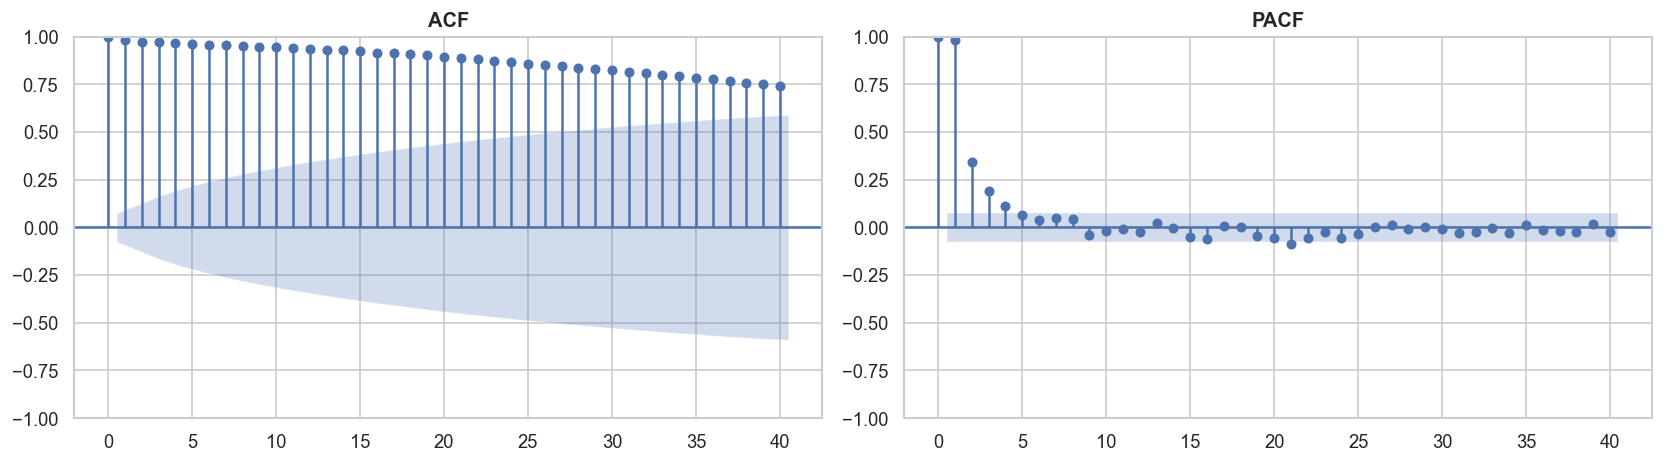

Saved: 19_acf_pacf.png


In [33]:
# ACF/PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train, lags=40, ax=axes[0])
plot_pacf(train, lags=40, ax=axes[1])
axes[0].set_title('ACF', fontweight='bold')
axes[1].set_title('PACF', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '19_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 19_acf_pacf.png")

Training ARIMA(5,1,2)...

Model: ARIMA
  MAE:  2.1427
  RMSE: 2.4541
  R²:   -3.1300
  MAPE: 10.12%


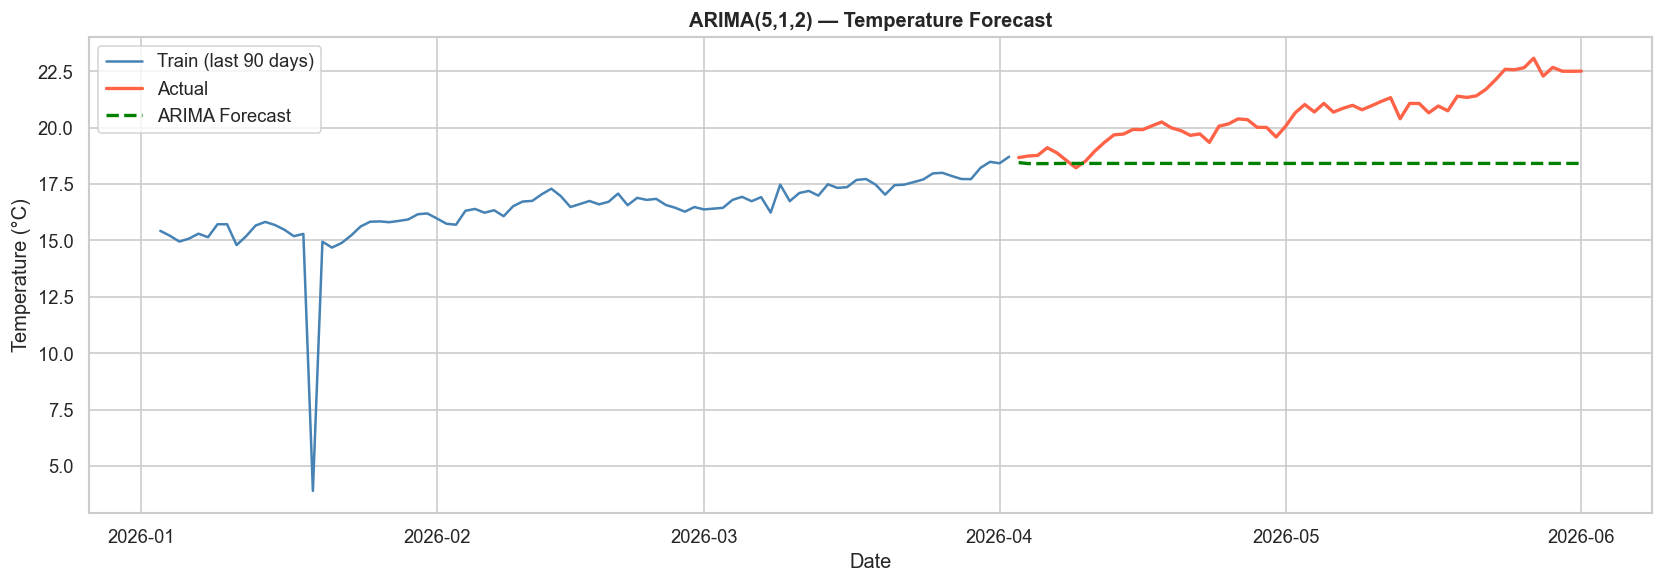

Saved: 20_arima_forecast.png


In [34]:
# Fit ARIMA
print("Training ARIMA(5,1,2)...")
arima_model = ARIMA(train, order=(5, 1, 2))
arima_fit   = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

arima_results = evaluate_model('ARIMA', test.values, arima_forecast.values)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-90:], train.values[-90:],
        color='steelblue', linewidth=1.5, label='Train (last 90 days)')
ax.plot(test.index, test.values,
        color='tomato', linewidth=2, label='Actual')
ax.plot(arima_forecast.index, arima_forecast.values,
        color='green', linewidth=2, linestyle='--', label='ARIMA Forecast')
ax.set_title('ARIMA(5,1,2) — Temperature Forecast', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '20_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 20_arima_forecast.png")

## 4. Model 2 — Linear Regression


Model: Linear Regression
  MAE:  0.2967
  RMSE: 0.3579
  R²:   0.9122
  MAPE: 1.45%


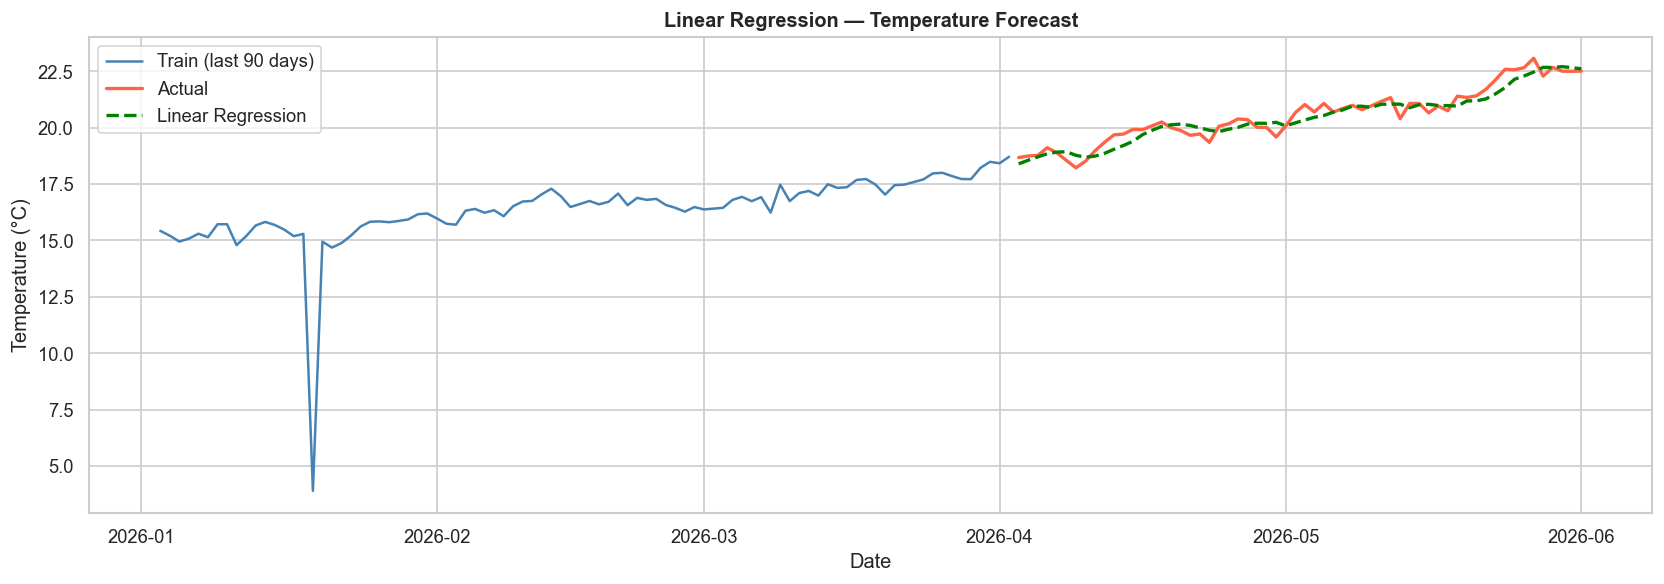

Saved: 21_linear_regression_forecast.png


In [35]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_results = evaluate_model('Linear Regression', y_test.values, lr_pred)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(X_train.index[-90:], y_train.values[-90:],
        color='steelblue', linewidth=1.5, label='Train (last 90 days)')
ax.plot(X_test.index, y_test.values,
        color='tomato', linewidth=2, label='Actual')
ax.plot(X_test.index, lr_pred,
        color='green', linewidth=2, linestyle='--', label='Linear Regression')
ax.set_title('Linear Regression — Temperature Forecast', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '21_linear_regression_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 21_linear_regression_forecast.png")

## 5. Model 3 — XGBoost

In [36]:
# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_results = evaluate_model('XGBoost', y_test.values, xgb_pred)

# Save model
xgb_model.save_model(MODELS_DIR / 'xgboost_temperature.json')
print("XGBoost model saved")


Model: XGBoost
  MAE:  0.2870
  RMSE: 0.3639
  R²:   0.9092
  MAPE: 1.39%
XGBoost model saved


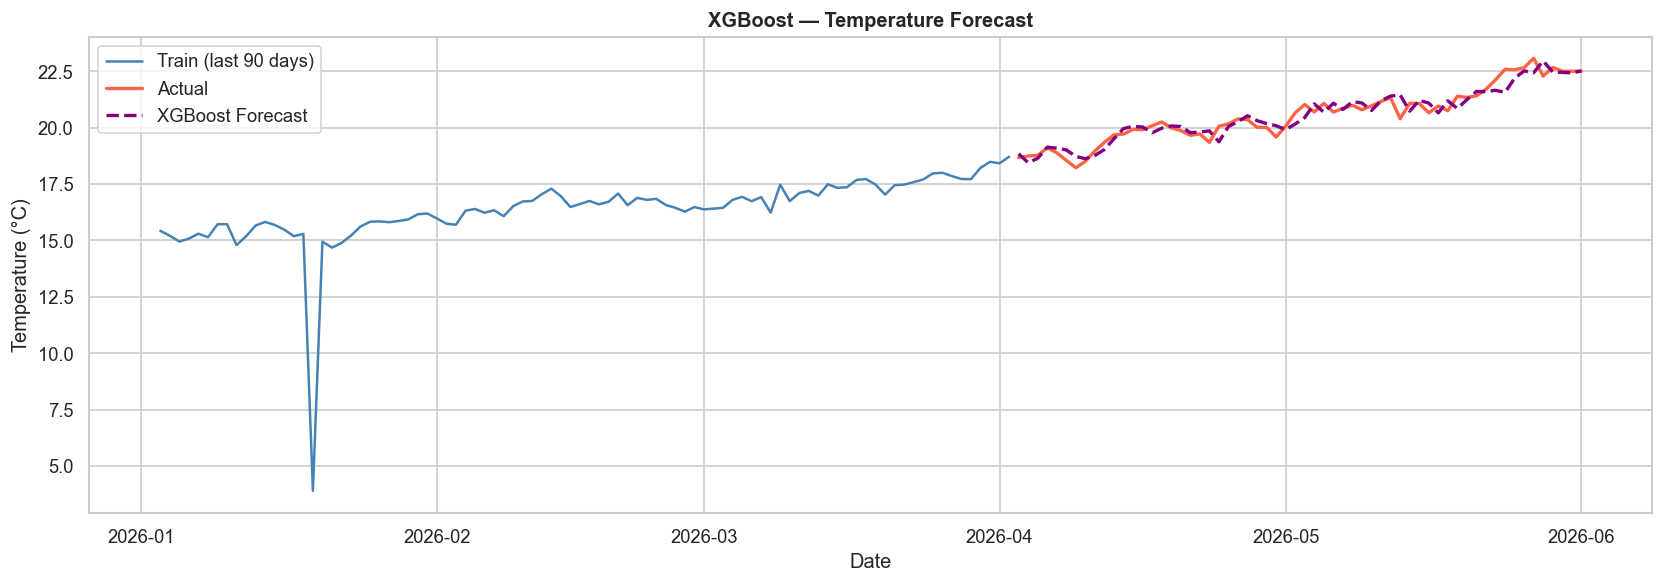

 Saved: 23_xgboost_forecast.png


In [37]:
# Plot XGBoost
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(X_train.index[-90:], y_train.values[-90:],
        color='steelblue', linewidth=1.5, label='Train (last 90 days)')
ax.plot(X_test.index, y_test.values,
        color='tomato', linewidth=2, label='Actual')
ax.plot(X_test.index, xgb_pred,
        color='purple', linewidth=2, linestyle='--', label='XGBoost Forecast')
ax.set_title('XGBoost — Temperature Forecast', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '23_xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 23_xgboost_forecast.png")

## 6. Model Comparison

In [38]:
# Results table
all_results = pd.DataFrame([arima_results, lr_results, xgb_results])
all_results = all_results.set_index('Model')

print("MODEL COMPARISON TABLE")
print(all_results.to_string())

MODEL COMPARISON TABLE
                      MAE    RMSE      R2   MAPE
Model                                           
ARIMA              2.1427  2.4541 -3.1300  10.12
Linear Regression  0.2967  0.3579  0.9122   1.45
XGBoost            0.2870  0.3639  0.9092   1.39


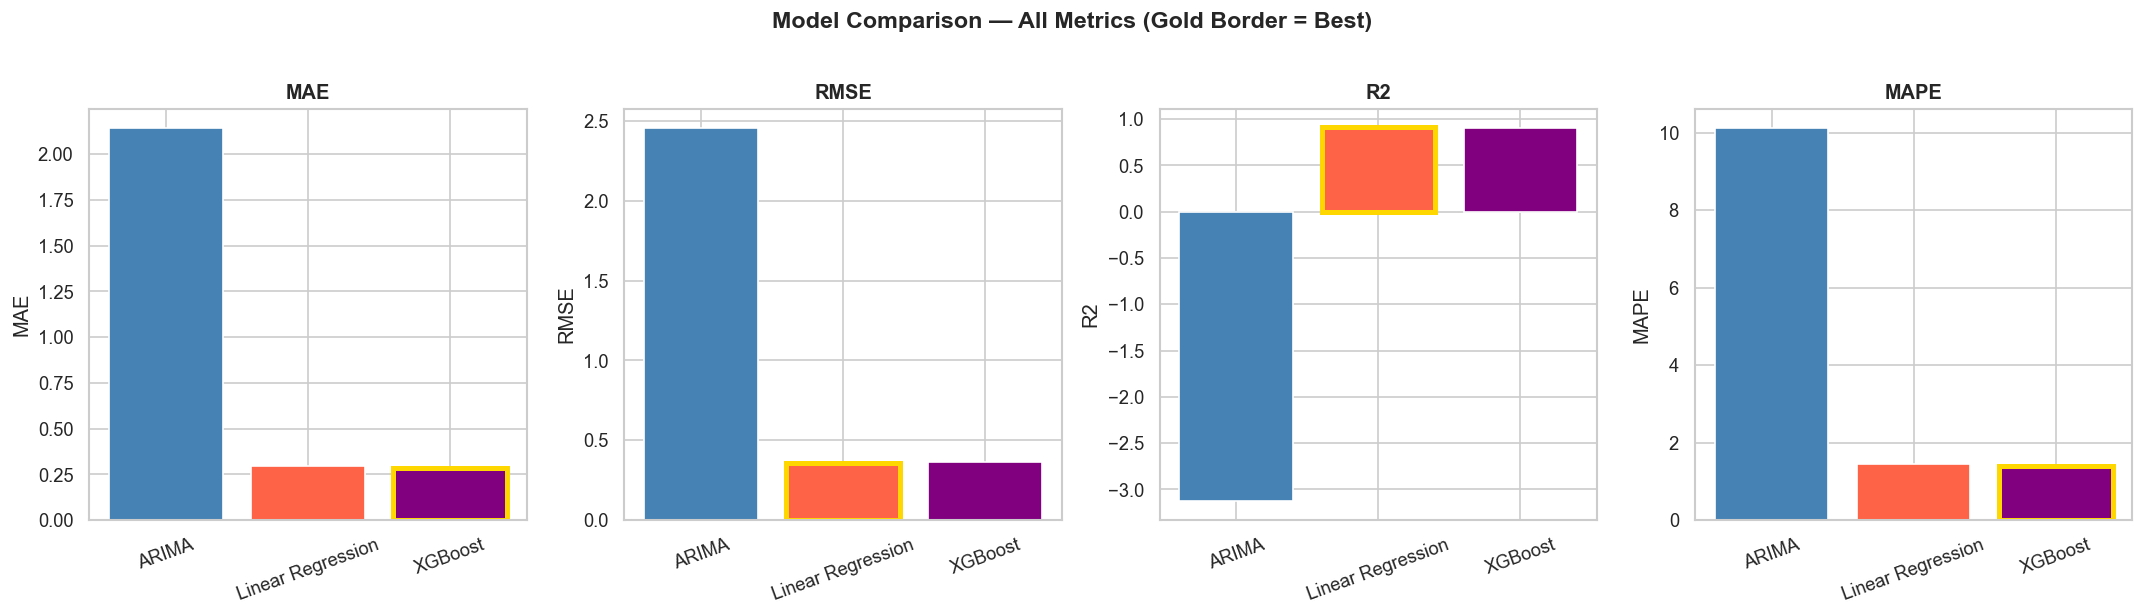

 Saved: 24_model_comparison.png


In [39]:
# Comparison bar charts
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['MAE', 'RMSE', 'R2', 'MAPE']
colors  = ['steelblue', 'tomato', 'purple']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(all_results.index, all_results[metric],
                       color=colors, edgecolor='white')
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=20)
    # Gold border on best
    best_idx = (all_results[metric].idxmin()
                if metric in ['MAE', 'RMSE', 'MAPE']
                else all_results[metric].idxmax())
    best_pos = list(all_results.index).index(best_idx)
    bars[best_pos].set_edgecolor('gold')
    bars[best_pos].set_linewidth(3)

plt.suptitle('Model Comparison — All Metrics (Gold Border = Best)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '24_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 24_model_comparison.png")

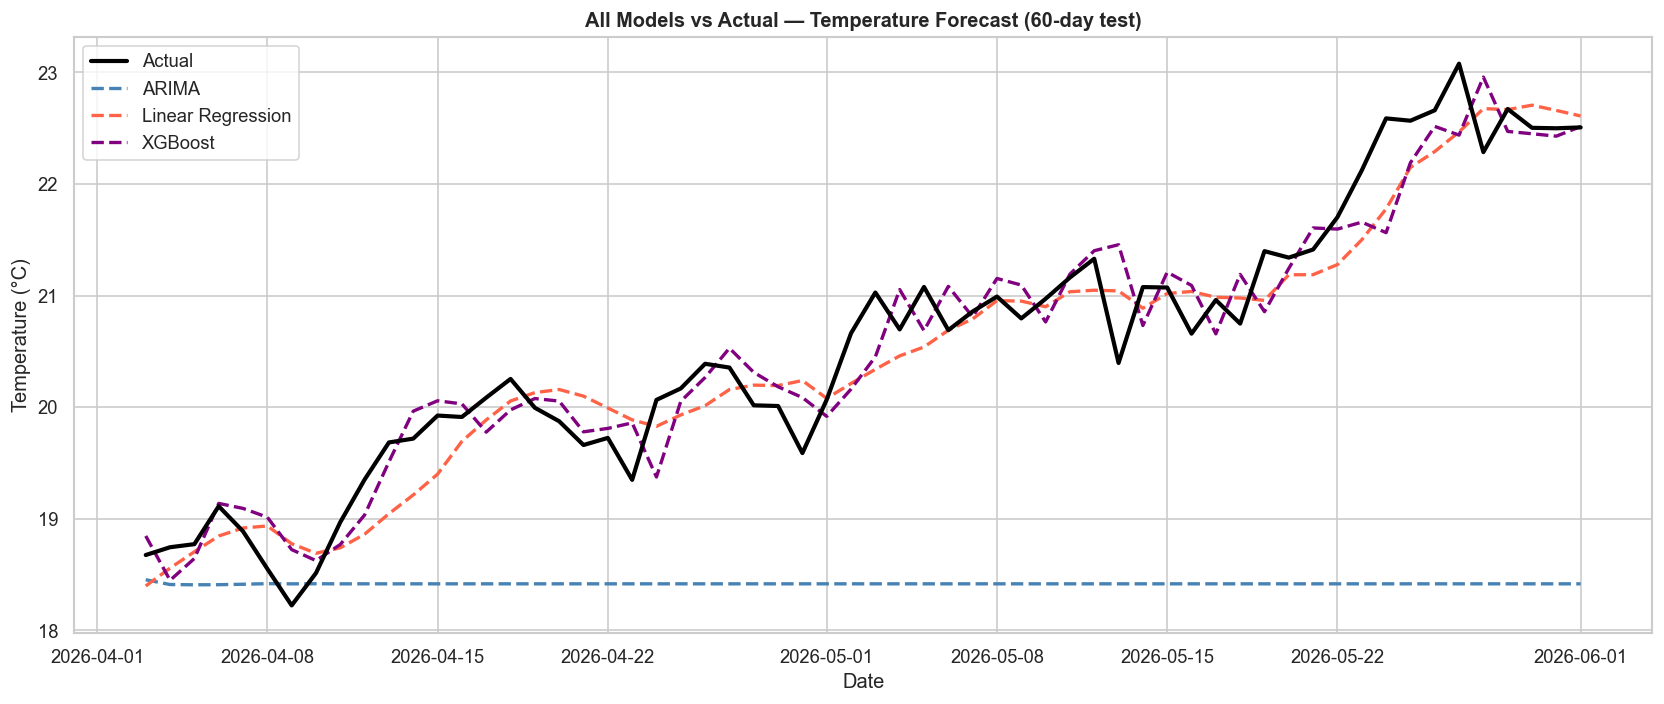

Saved: 25_all_models_comparison.png


In [40]:
# All forecasts on one plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test.index, test.values,
        color='black', linewidth=2.5, label='Actual', zorder=5)
ax.plot(arima_forecast.index, arima_forecast.values,
        color='steelblue', linewidth=2, linestyle='--', label='ARIMA')
ax.plot(X_test.index, lr_pred,
        color='tomato', linewidth=2, linestyle='--', label='Linear Regression')
ax.plot(X_test.index, xgb_pred,
        color='purple', linewidth=2, linestyle='--', label='XGBoost')
ax.set_title('All Models vs Actual — Temperature Forecast (60-day test)',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '25_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 25_all_models_comparison.png")